In [1]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

In [2]:
# clear the model predictions csv
with open('RandomForestResult.csv', 'w') as file:
    file.write('')

In [3]:
# Load the filtered dataset
data = pd.read_csv('filtered_customer_tier_data.csv')

In [4]:
# Standardize the formatting to avoid case and whitespace issues
data['Status'] = data['Status'].str.strip().str.title()

# Count specific statuses
converted_count = data['Status'].value_counts().get('Converted', 0)
other_quote_converted_count = data['Status'].value_counts().get('Other Quote Converted', 0)
not_converted_count = data['Status'].value_counts().get('Not Converted', 0)

# Print the results
print(f"Converted: {converted_count}")
print(f"Other Quote Converted: {other_quote_converted_count}")
print(f"Not Converted: {not_converted_count}")

Converted: 75385
Other Quote Converted: 271432
Not Converted: 51404


In [5]:
# Clean up whitespace and capitalization first, just in case
data['Status'] = data['Status'].str.strip().str.title()

# Drop rows where Status is 'Other Quote Converted'
data = data[data['Status'] != 'Other Quote Converted']

# Optional: Verify the drop worked
print(data['Status'].value_counts())

Status
Converted        75385
Not Converted    51404
Name: count, dtype: int64


In [6]:
# Define features and target
X = data[['CustomerTier', 'PercentProfit']]
y = data['Status']

In [7]:
# Encode the target variable 'QuoteStatus' as it is categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [8]:
# # Apply SMOTE before splitting to balance the 'Not Converted' class in the entire dataset
# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

In [9]:
# Step 1: Split your original data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [10]:
# Initialize the RandomForest Tree model
clf = RandomForestClassifier(random_state=42)

In [11]:
# Train the model on the resampled training data
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

In [13]:
# Get confidence percentages (probabilities of predictions)
y_prob = clf.predict_proba(X_test)
confidence = np.max(y_prob, axis=1) * 100  # Convert to percentage

In [14]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.92


In [15]:
# Detailed classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

               precision    recall  f1-score   support

    Converted       0.91      0.95      0.93     15077
Not Converted       0.93      0.87      0.90     10281

     accuracy                           0.92     25358
    macro avg       0.92      0.91      0.91     25358
 weighted avg       0.92      0.92      0.92     25358



In [16]:
# Prepare the output data for CSV
output_data = X_test.copy()
output_data['Actual Status'] = label_encoder.inverse_transform(y_test)
output_data['Predicted Status'] = label_encoder.inverse_transform(y_pred)
output_data['Confidence (%)'] = confidence

In [17]:
# Save to CSV
output_data.to_csv('RandomForestResult.csv', index=False)
print("Predictions have been saved to 'RandomForestResult.csv'")

Predictions have been saved to 'RandomForestResult.csv'


In [18]:
## Visual analysis of the RandomForest results

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [20]:
data = pd.read_csv('RandomForestResult.csv')

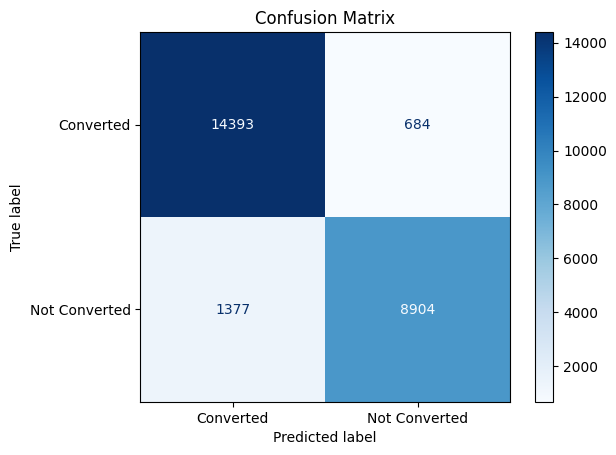

In [21]:
# Confusion Matrix
cm = confusion_matrix(data['Actual Status'], data['Predicted Status'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Converted', 'Not Converted'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


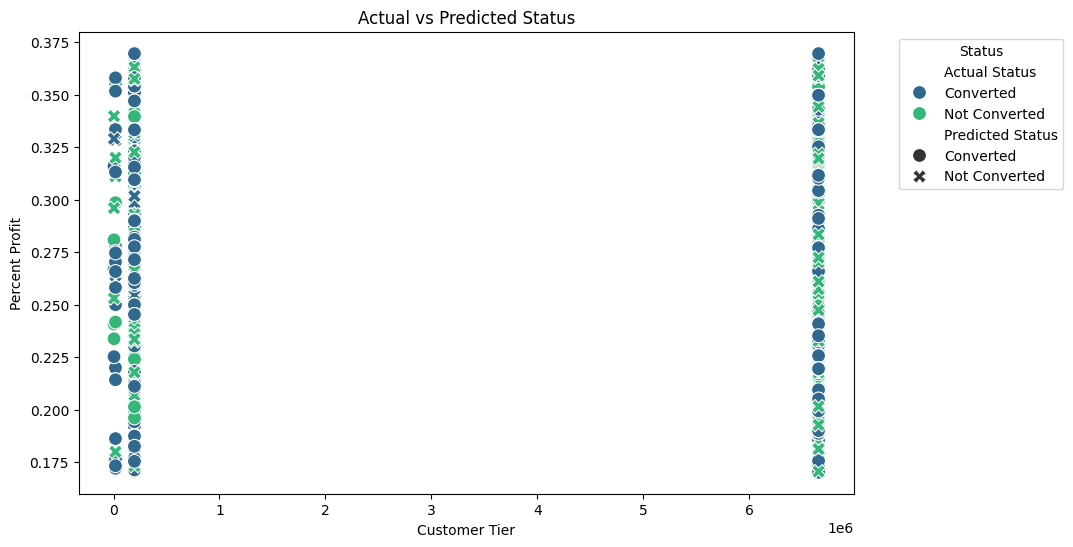

In [22]:
# Scatter Plot of Features (CustomerTier vs PercentProfit)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='CustomerTier', y='PercentProfit', hue='Actual Status', style='Predicted Status',
    data=data, palette='viridis', markers=['o', 'X'], s=100
)
plt.title('Actual vs Predicted Status')
plt.xlabel('Customer Tier')
plt.ylabel('Percent Profit')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

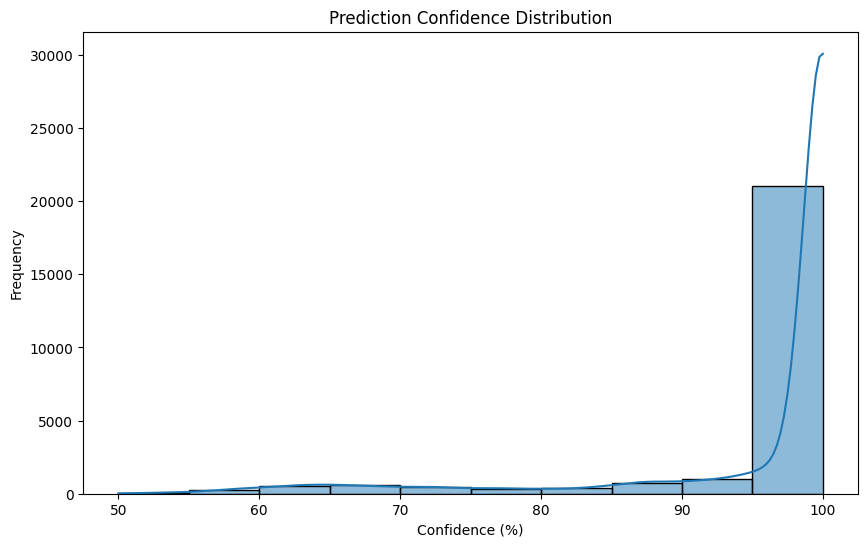

In [23]:
# Histogram of Confidence Percentages
plt.figure(figsize=(10, 6))
sns.histplot(data['Confidence (%)'], bins=10, kde=True)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Confidence (%)')
plt.ylabel('Frequency')
plt.show()